# T-Test for Same vs. Different Operating and Ticket Carriers

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
q3_2024 = pd.read_csv('../../data/2024_q3.csv')
q4_2024 = pd.read_csv('../../data/2024_q4.csv')
q1_2025 = pd.read_csv('../../data/2025_q1.csv')
q2_2025 = pd.read_csv('../../data/2025_q2.csv')

In [ ]:
q3_2024 = pd.read_csv('/Volumes/Extreme Pro/DSAN-5200/final-project/2024_q3.csv')
q4_2024 = pd.read_csv('/Volumes/Extreme Pro/DSAN-5200/final-project/2024_q4.csv')
q1_2025 = pd.read_csv('/Volumes/Extreme Pro/DSAN-5200/final-project/2025_q1.csv')
q2_2025 = pd.read_csv('/Volumes/Extreme Pro/DSAN-5200/final-project/2025_q2.csv')

In [4]:
df = pd.concat([q3_2024, q4_2024, q1_2025, q2_2025], ignore_index=True)


In [5]:
df = df[df['REPORTING_CARRIER'] != '99']
df = df[df['TICKET_CARRIER'] != '99']
df = df[df['OPERATING_CARRIER'] != '99']

In [6]:
df.shape

(27378923, 15)

In [7]:
same_carrier = df['TICKET_CARRIER'] == df['OPERATING_CARRIER']

# Count how many are the same
num_same = same_carrier.sum()

# Total rows
total = len(df)

# Percentage of matches
pct_same = num_same / total * 100

print(f"Same carrier count: {num_same:,}")
print(f"Total rows: {total:,}")
print(f"Percentage same: {pct_same:.2f}%")

Same carrier count: 23,609,712
Total rows: 27,378,923
Percentage same: 86.23%


In [8]:
same_carrier_df = df[same_carrier]
different_carrier_df = df[~same_carrier]

print(same_carrier_df.shape)
print(different_carrier_df.shape)

(23609712, 15)
(3769211, 15)


In [9]:
same_carrier_df.columns

Index(['YEAR', 'QUARTER', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'DEST_AIRPORT_ID',
       'DEST', 'REPORTING_CARRIER', 'TICKET_CARRIER', 'OPERATING_CARRIER',
       'BULK_FARE', 'PASSENGERS', 'MARKET_FARE', 'MARKET_DISTANCE',
       'NONSTOP_MILES', 'MKT_GEO_TYPE'],
      dtype='object')

In [10]:
same_carrier_df = same_carrier_df.loc[:, ['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE']]

In [11]:
different_carrier_df = different_carrier_df.loc[:, ['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE']]

In [12]:
same_carrier_df.columns

Index(['TICKET_CARRIER', 'OPERATING_CARRIER', 'MARKET_FARE'], dtype='object')

In [13]:
from scipy import stats

In [14]:
col1 = same_carrier_df['MARKET_FARE'].dropna()
col2 = different_carrier_df['MARKET_FARE'].dropna()

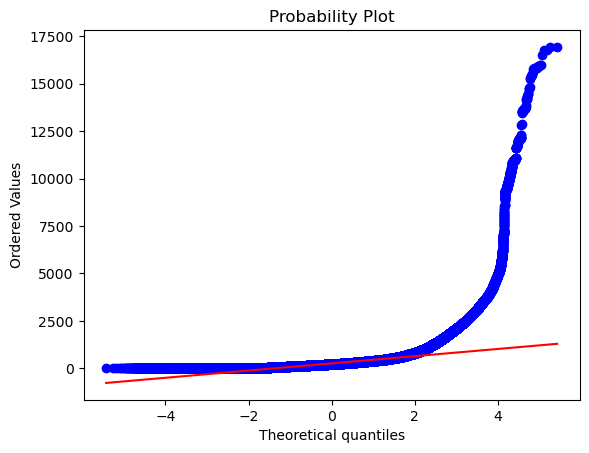

In [15]:
stats.probplot(col1, dist="norm", plot=plt)
plt.show()

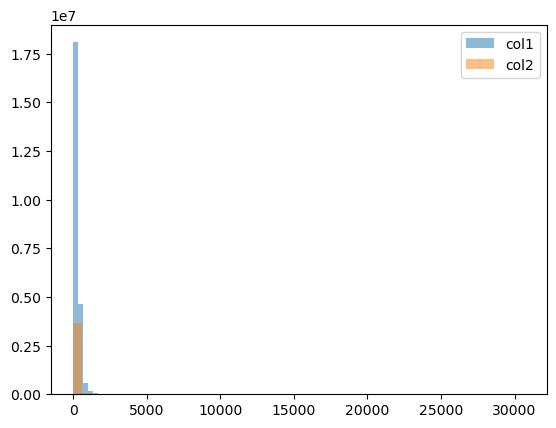

In [16]:
plt.hist(col1, bins=50, alpha=0.5, label='col1')
plt.hist(col2, bins=50, alpha=0.5, label='col2')
plt.legend()
plt.show()

In [17]:


# Replace with your actual data sources

# Mann–Whitney U test
stat, p_value = stats.mannwhitneyu(col1, col2, alternative='two-sided')

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 42854243996630.5
p-value: 0.0


In [19]:
## downsampling

col1_sample = col1.sample(10000, random_state=5200)
col2_sample = col2.sample(10000, random_state=5200)

stat, p_value = stats.mannwhitneyu(col1_sample, col2_sample)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 47927229.5
p-value: 3.831933444662033e-07


In [ ]:
## bootstrapping

import numpy as np

def bootstrap_median_diff(col1, col2, n_boot=1000):
    diffs = []
    
    for _ in range(n_boot):
        sample1 = np.random.choice(col1, size=5000, replace=True)
        sample2 = np.random.choice(col2, size=5000, replace=True)
        
        diff = np.median(sample1) - np.median(sample2)
        diffs.append(diff)
    
    return np.array(diffs)

boot_diffs = bootstrap_median_diff(col1.values, col2.values)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print("95% CI:", ci_lower, ci_upper)

## bootstrapping yields CI completely below 0. Price of flights where ticket and operating carrier are the same are lower with a median difference of $4-16. Technically this is statistically significant but in practice $4-16 is nothing lol.

95% CI: -16.0 -4.0


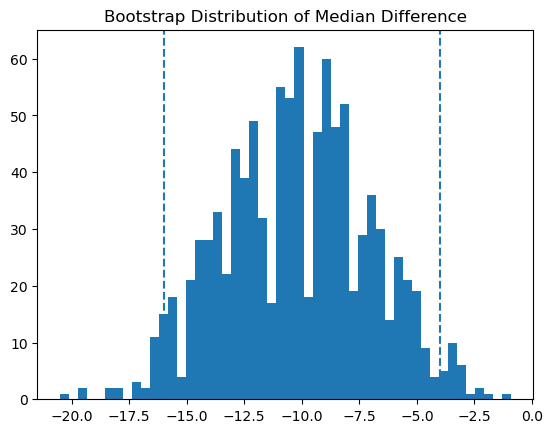

In [22]:
import matplotlib.pyplot as plt

plt.hist(boot_diffs, bins=50)
plt.axvline(ci_lower, linestyle='--')
plt.axvline(ci_upper, linestyle='--')
plt.title("Bootstrap Distribution of Median Difference")
plt.show()

In [24]:
from scipy.stats import ks_2samp

## KS test 
stat, p = ks_2samp(col1, col2)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 0.06229420629207058
p-value: 3.831933444662033e-07
